In [1]:
import torch
import ray
import os
import pandas as pd
import numpy as np
import re
from scipy.stats import spearmanr

from PIL import Image
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

# Define which slides you want to process here
slide_path = "/mnt/projects/ri_scale/privagams/prostate_normalized"

/home/jovyan/similarity/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-12-04 09:54:29,695	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


# Code for similarity taken from silde_embeddings.py

In [2]:
def load_parquet(path): 
    data = pd.read_parquet(path)
    return data

def load_embeddings(slide_path, file_name):
    print(slide_path)
    dirs_to_process = sorted([
        d for d in os.listdir(slide_path) 
        if os.path.isdir(os.path.join(slide_path, d)) and not d.startswith(".")
    ])
    embeddings: List[torch.Tensor] = []
    labels = []

    for dir in dirs_to_process:
        embeddings_path = os.path.join(slide_path, dir, file_name)
        tensor = torch.tensor(load_parquet(embeddings_path).embedding[0], dtype=torch.float32)
        embeddings.append(tensor)
        labels.append(dir)
    
    emb_matrix = torch.stack(embeddings, dim=0)

    return (emb_matrix, labels)

def save_simmilarity(sim_matrix, labels, name):

    sim_matrix_mod = sim_matrix.clone()
    sim_matrix_mod.fill_diagonal_(-2.0)
    most_similar_indices = torch.argmax(sim_matrix_mod, dim=1)

    hits = 0
    for i in range(len(labels)):
        slide_a = labels[i]
        slide_b = labels[most_similar_indices[i]]
        #print(slide_a[-14:])
        #print(slide_b[-14:])
        if (slide_a[-14:] == slide_b[-14:]):
            hits += 1
        
        print(f"slide {labels[i]} is most simmilar with slide {labels[most_similar_indices[i]]}")
    print(f"perfect hits: {hits}")


    #print(f"Number of MIDI/FLASH matches for {name} is {count}, R_s= {count/len(x_labels)}")
    #print(f"length of {name} is {len(x_labels)}")
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        sim_matrix,
        xticklabels=labels,
        yticklabels=labels,
        cmap="viridis",
        annot=True,
        fmt=".2f",                    
        linewidths=0.5,
        linecolor="gray",
        cbar_kws={"label": f"{name} similarity"},
        annot_kws={"fontsize": 10}
    )
    plt.title(f"Pairwise {name} similarity of slide embeddings")
    plt.xticks(rotation=45, ha="right", fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()

    return 0

def cos_simmilarity(slide_path, file_name):
    emb_matrix, labels = load_embeddings(slide_path, file_name)
    emb_matrix = torch.sign(emb_matrix) * torch.sqrt(torch.abs(emb_matrix))
    X_norm = F.normalize(emb_matrix, p=2, dim=1)
    cosine_sim = X_norm @ X_norm.T
    return save_simmilarity(cosine_sim, labels, f"cos_{file_name}")

def l1_simmilarity(slide_path, file_name):
    emb_matrix, labels = load_embeddings(slide_path, file_name)
    l1_distance_matrix = torch.cdist(emb_matrix, emb_matrix, p=1)

    D_min = l1_distance_matrix.min()
    D_max = l1_distance_matrix.max()

    # 2. Normalizace matice na rozsah [0, 1]
    # (Odečteme minimum a vydělíme rozsahem)
    D_range = D_max - D_min
    # Ošetření případu, kdy D_range je nula (např. matice plná stejných hodnot)
    if D_range == 0:
        similarity_matrix = torch.ones_like(l1_distance_matrix)
    else:
        D_norm = (l1_distance_matrix - D_min) / D_range
        
        # 3. Inverze (Odečtení od 1)
        similarity_matrix = 1 - D_norm

    return save_simmilarity(similarity_matrix, labels, f"L1_{file_name}")

def l2_simmilarity(slide_path, file_name):
    emb_matrix, labels = load_embeddings(slide_path, file_name)
    l2_distance_matrix = torch.cdist(emb_matrix, emb_matrix, p=2)

    D_min = l2_distance_matrix.min()
    D_max = l2_distance_matrix.max()

    # 2. Normalizace matice na rozsah [0, 1]
    # (Odečteme minimum a vydělíme rozsahem)
    D_range = D_max - D_min
    # Ošetření případu, kdy D_range je nula (např. matice plná stejných hodnot)
    if D_range == 0:
        similarity_matrix = torch.ones_like(l2_distance_matrix)
    else:
        D_norm = (l2_distance_matrix - D_min) / D_range
        
        # 3. Inverze (Odečtení od 1)
        similarity_matrix = 1 - D_norm

    return save_simmilarity(similarity_matrix, labels, f"L2_{file_name}")

# Code for playing directly with tiles embeddings

In [3]:
def load_parquet(path): 
    data = pd.read_parquet(path)
    return data

def load_tiles_embeddings(slide_path):
    dirs_to_process = sorted([
        d for d in os.listdir(slide_path) 
        if os.path.isdir(os.path.join(slide_path, d)) and not d.startswith(".")
    ])
    embeddings: List[List[torch.Tensor]] = []
    labels = []

    for dir in dirs_to_process:
        embeddings_path = os.path.join(slide_path, dir, "tiles.parquet")
        embedding_array = np.array(load_parquet(embeddings_path).embedding.tolist())
        embedding_matrix = torch.tensor(embedding_array, dtype=torch.float32)
        embeddings.append(embedding_matrix)
        labels.append(dir)
    

    return (embeddings, labels)

#### getting tiles embedding for each slide in slide_path

In [4]:
matrix, labels = load_tiles_embeddings(slide_path)

#### generating mean of all tiles embedding to act as slide embedding

In [15]:
for i in range(len(labels)):
    wsi_embedding = torch.mean(matrix[i], dim=0)
    label = labels[i]
    output_df = pd.DataFrame({
        'slide_id': label,
        'embedding': [wsi_embedding.tolist()],
    })
    output_df.to_parquet(f"{slide_path}/{label}/slide_mean.parquet", index=False)

### Statistical pooling

In [16]:
for i in range(len(labels)):
    mean_vector = torch.mean(matrix[i], dim=0)
    std_dev_vector = torch.std(matrix[i], dim=0)
    wsi_embedding = torch.cat((mean_vector, std_dev_vector), dim=0)

    label = labels[i]
    output_df = pd.DataFrame({
        'slide_id': label,
        'embedding': [wsi_embedding.tolist()],
    })
    output_df.to_parquet(f"{slide_path}/{label}/slide_statistic.parquet", index=False)



slide FLASH2021_6802-01-T is most simmilar with slide MIDI2021_7180-01-T
slide FLASH2021_6915-02-T is most simmilar with slide FLASH2021_7009-01-T
slide FLASH2021_6916-02-T is most simmilar with slide FLASH2021_6915-02-T
slide FLASH2021_6921-02-T is most simmilar with slide MIDI2021_6921-02-T
slide FLASH2021_6963-03-T1 is most simmilar with slide FLASH2021_7071-01-T1
slide FLASH2021_7009-01-T is most simmilar with slide FLASH2021_6915-02-T
slide FLASH2021_7065-01-T1 is most simmilar with slide FLASH2021_7071-01-T1
slide FLASH2021_7071-01-T1 is most simmilar with slide FLASH2021_6963-03-T1
slide FLASH2021_7180-01-T is most simmilar with slide FLASH2021_7181-02-T
slide FLASH2021_7181-02-T is most simmilar with slide FLASH2021_7180-01-T
slide MIDI2021_6802-01-T is most simmilar with slide MIDI2021_7071-01-T1
slide MIDI2021_6915-02-T is most simmilar with slide MIDI2021_6921-02-T
slide MIDI2021_6916-02-T is most simmilar with slide MIDI2021_6963-03-T
slide MIDI2021_6921-02-T is most simmil

/tmp/ipykernel_5808/27208541.py:44: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 8))


slide FLASH2021_5638-02-T is most simmilar with slide FLASH2021_7036-02-T
slide FLASH2021_5956-02-T is most simmilar with slide FLASH2021_7187-02-T
slide FLASH2021_6088-02-T is most simmilar with slide MIDI2021_6088-02-T
slide FLASH2021_6113-01-T is most simmilar with slide MIDI2021_6113-01-T
slide FLASH2021_6325-02-T is most simmilar with slide MIDI2021_6325-02-T
slide FLASH2021_6432-01-T is most simmilar with slide MIDI2021_6432-01-T
slide FLASH2021_6838-02-T is most simmilar with slide FLASH2021_6843-02-T
slide FLASH2021_6843-02-T is most simmilar with slide MIDI2021_6843-02-T
slide FLASH2021_7036-02-T is most simmilar with slide MIDI2021_7036-02-T
slide FLASH2021_7187-02-T is most simmilar with slide FLASH2021_5956-02-T
slide MIDI2021_5638-02-T is most simmilar with slide MIDI2021_7036-02-T
slide MIDI2021_5956-02-T is most simmilar with slide MIDI2021_7187-02-T
slide MIDI2021_6088-02-T is most simmilar with slide FLASH2021_6088-02-T
slide MIDI2021_6113-01-T is most simmilar with sl

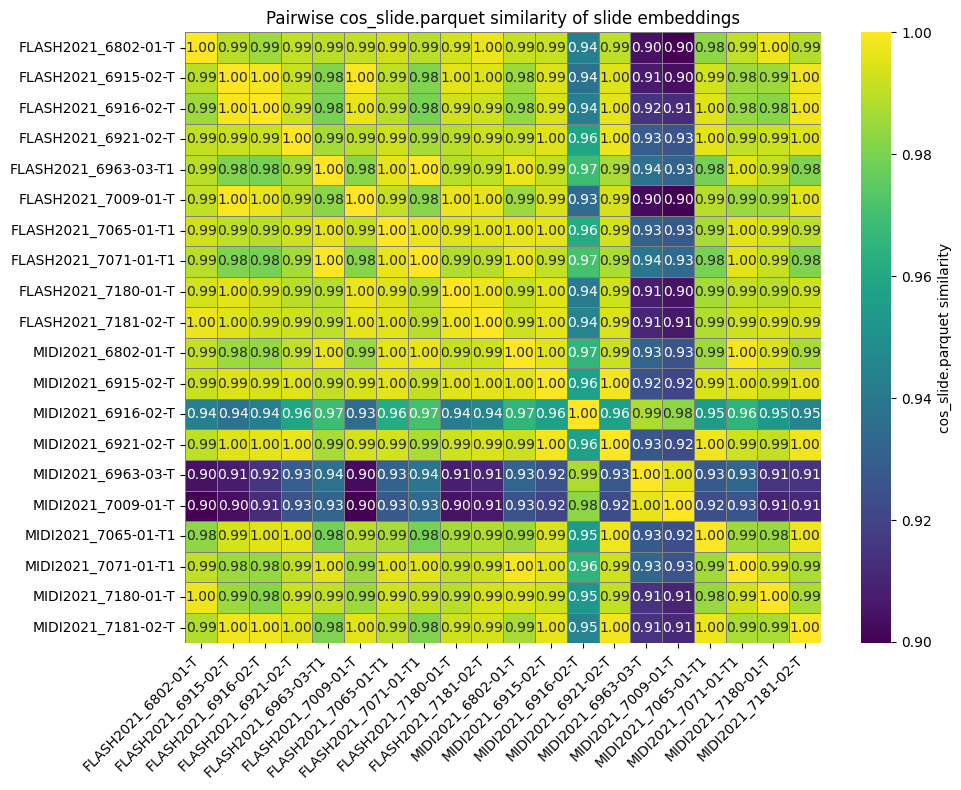

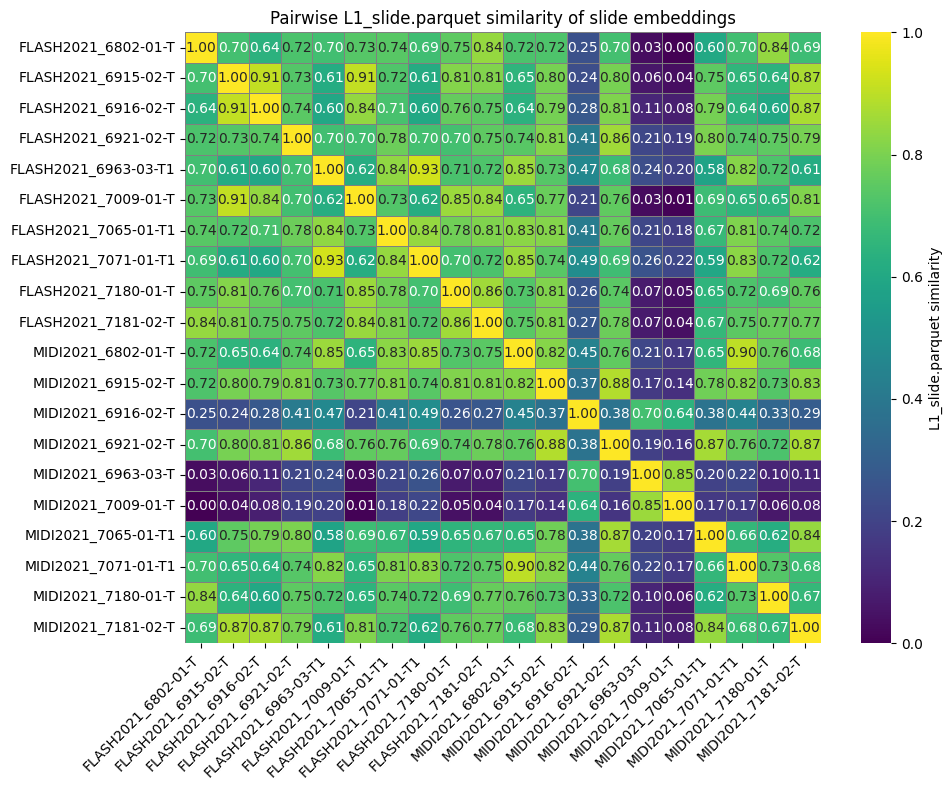

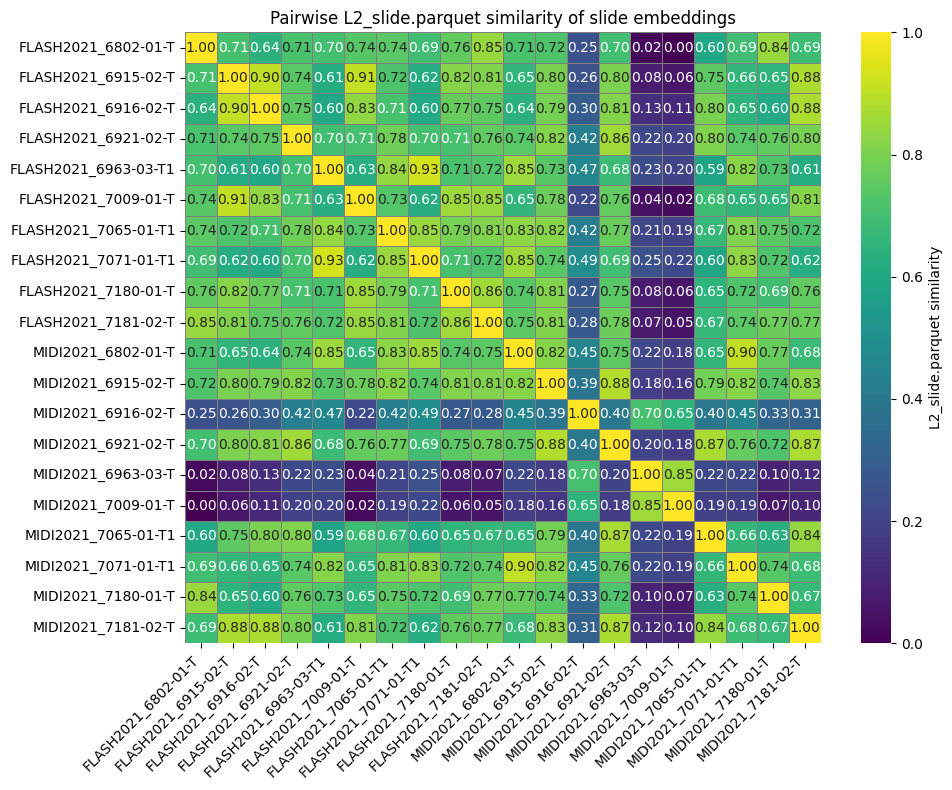

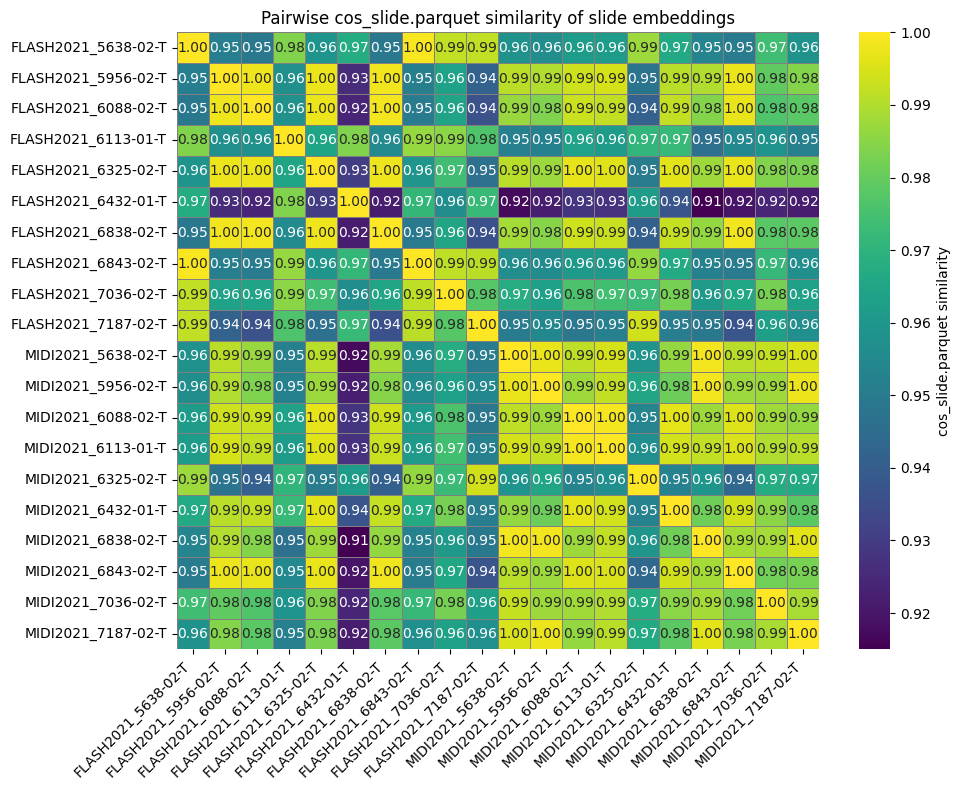

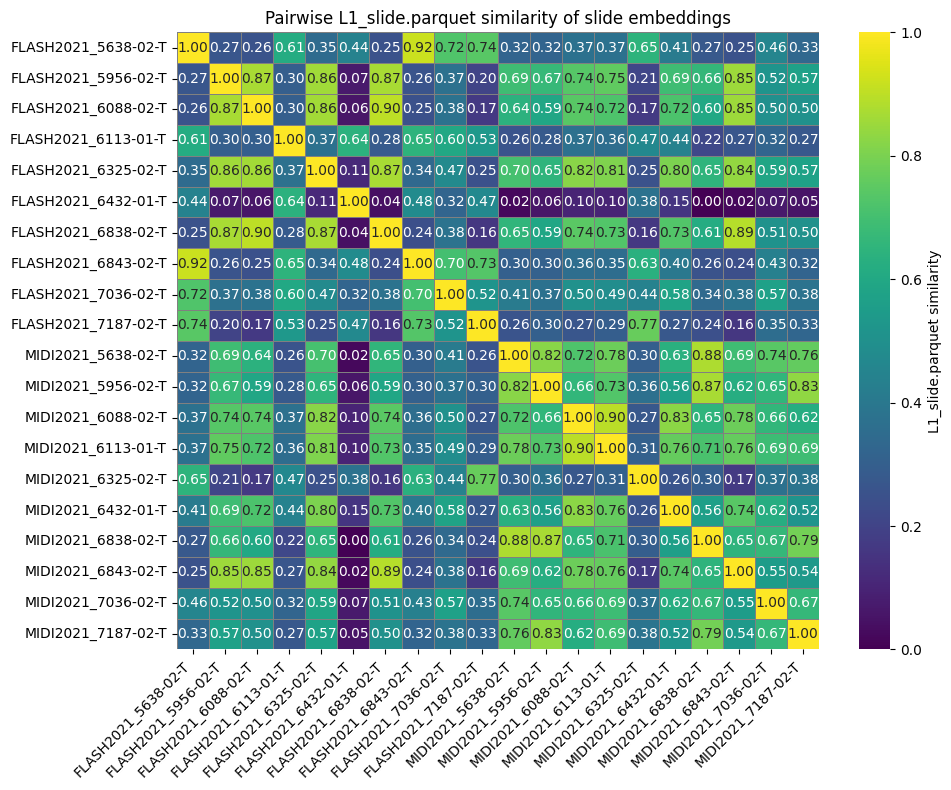

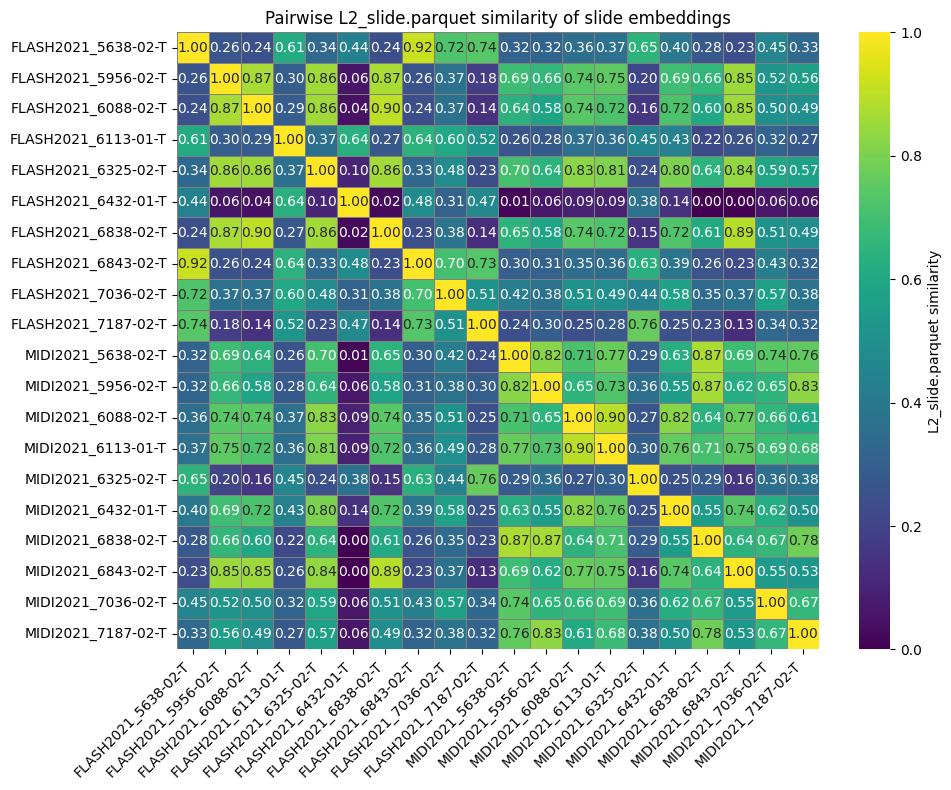

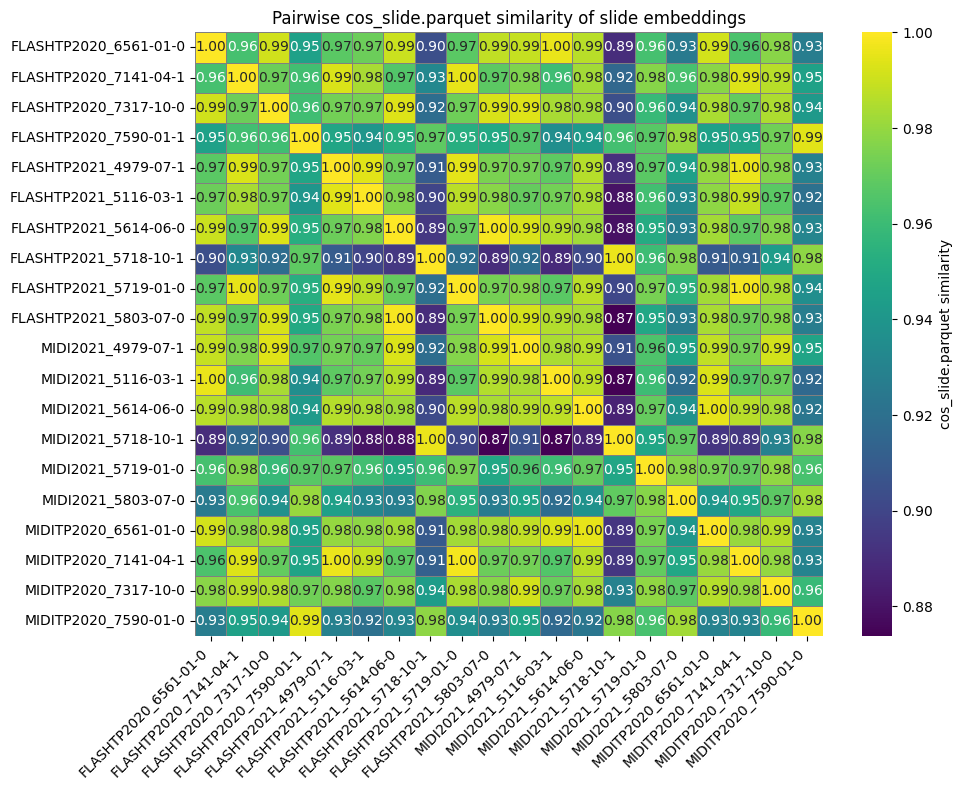

In [ ]:
slide_paths = [
   "/mnt/projects/ri_scale/privagams/breast_rgb_filter",
   "/mnt/projects/ri_scale/privagams/colon_rgb_filter",
   "/mnt/projects/ri_scale/privagams/prostate_rgb_filter",
]

slide_paths_stains = [
   "/mnt/projects/ri_scale/privagams/breast_stains",
   "/mnt/projects/ri_scale/privagams/colon_stains",
   "/mnt/projects/ri_scale/privagams/prostate_stains",
]

embeddings_files = [
   "slide.parquet",
   "slide_mean.parquet",
   "slide_statistic.parquet"
]

for file in embeddings_files:
   cos = 0
   l1 = 0
   l2 = 0
   for slide_path in slide_paths_stains:
      cos += cos_simmilarity(slide_path, file)
      l1 += l1_simmilarity(slide_path, file)
      l2 += l2_simmilarity(slide_path, file)
   
   print()
   print(file)
   length = 30
   print(f"length={length}\ncos={cos} cosR_s={cos/length},\nl1={l1} L1R_s={l1/length},\nl2={l2} L2R_s={l2/length}")


In [ ]:
slide_paths = [
   "/mnt/projects/ri_scale/privagams/breast_rgb_filter",
   "/mnt/projects/ri_scale/privagams/colon_rgb_filter",
   "/mnt/projects/ri_scale/privagams/prostate_rgb_filter",
]

slide_paths_stains = [
   "/mnt/projects/ri_scale/privagams/breast_stains",
   "/mnt/projects/ri_scale/privagams/colon_stains",
   "/mnt/projects/ri_scale/privagams/prostate_stains",
]

embeddings_files = [
   "slide.parquet",
   "slide_mean.parquet",
   "slide_statistic.parquet",
   "slide_vlad.parquet"
]

for file in embeddings_files:
   cos = 0
   l1 = 0
   l2 = 0
   for slide_path in slide_paths:
      cos += cos_simmilarity(slide_path, file)
      l1 += l1_simmilarity(slide_path, file)
      l2 += l2_simmilarity(slide_path, file)
   
   print()
   print(file)
   length = 30
   print(f"length={length}\ncos={cos} cosR_s={cos/length},\nl1={l1} L1R_s={l1/length},\nl2={l2} L2R_s={l2/length}")



slide.parquet
length=30
cos=16 cosR_s=0.5333333333333333,
l1=18 L1R_s=0.6,
l2=16 L2R_s=0.5333333333333333

slide_mean.parquet
length=30
cos=29 cosR_s=0.9666666666666667,
l1=29 L1R_s=0.9666666666666667,
l2=27 L2R_s=0.9

slide_statistic.parquet
length=30
cos=29 cosR_s=0.9666666666666667,
l1=29 L1R_s=0.9666666666666667,
l2=28 L2R_s=0.9333333333333333


In [ ]:
slide_path = "/mnt/projects/ri_scale/privagams/breast_rgb_filter"
print()
print(slide_path)
print()
print("#"*20 + " slide encoder " + "#"*20)
cos_simmilarity(slide_path, "slide.parquet")
l1_simmilarity(slide_path, "slide.parquet")
l2_simmilarity(slide_path, "slide.parquet")

print()
print("#"*20 + " Mean of tile embeddings " + "#"*20)
cos_simmilarity(slide_path, "slide_mean.parquet")
l1_simmilarity(slide_path, "slide_mean.parquet")
l2_simmilarity(slide_path, "slide_mean.parquet")

print()
print("#"*20 + " Mean of statistic pooling " + "#"*20)
cos_simmilarity(slide_path, "slide_statistic.parquet")
l1_simmilarity(slide_path, "slide_statistic.parquet")
l2_simmilarity(slide_path, "slide_statistic.parquet")

slide_path = "/mnt/projects/ri_scale/privagams/colon_rgb_filter"
print()
print(slide_path)
print()
print("#"*20 + " slide encoder " + "#"*20)
cos_slide += cos_simmilarity(slide_path, "slide.parquet")
l1_simmilarity(slide_path, "slide.parquet")
l2_simmilarity(slide_path, "slide.parquet")

print()
print("#"*20 + " Mean of tile embeddings " + "#"*20)
cos_simmilarity(slide_path, "slide_mean.parquet")
l1_simmilarity(slide_path, "slide_mean.parquet")
l2_simmilarity(slide_path, "slide_mean.parquet")

print()
print("#"*20 + " Mean of statistic pooling " + "#"*20)
cos_simmilarity(slide_path, "slide_statistic.parquet")
l1_simmilarity(slide_path, "slide_statistic.parquet")
l2_simmilarity(slide_path, "slide_statistic.parquet")

slide_path = "/mnt/projects/ri_scale/privagams/prostate_rgb_filter"
print()
print(slide_path)
print()
print("#"*20 + " slide encoder " + "#"*20)
cos_slide += cos_simmilarity(slide_path, "slide.parquet")
l1_simmilarity(slide_path, "slide.parquet")
l2_simmilarity(slide_path, "slide.parquet")

print()
print("#"*20 + " Mean of tile embeddings " + "#"*20)
cos_simmilarity(slide_path, "slide_mean.parquet")
l1_simmilarity(slide_path, "slide_mean.parquet")
l2_simmilarity(slide_path, "slide_mean.parquet")

print()
print("#"*20 + " Mean of statistic pooling " + "#"*20)
cos_simmilarity(slide_path, "slide_statistic.parquet")
l1_simmilarity(slide_path, "slide_statistic.parquet")
l2_simmilarity(slide_path, "slide_statistic.parquet")


/mnt/projects/ri_scale/privagams/breast_rgb_filter

#################### slide encoder ####################
Number of MIDI/FLASH matches for cos_slide.parquet is 5, R_s= 0.5
Number of MIDI/FLASH matches for L1_slide.parquet is 6, R_s= 0.6
Number of MIDI/FLASH matches for L2_slide.parquet is 5, R_s= 0.5

#################### Mean of tile embeddings ####################
Number of MIDI/FLASH matches for cos_slide_mean.parquet is 10, R_s= 1.0
Number of MIDI/FLASH matches for L1_slide_mean.parquet is 10, R_s= 1.0
Number of MIDI/FLASH matches for L2_slide_mean.parquet is 9, R_s= 0.9

#################### Mean of statistic pooling ####################
Number of MIDI/FLASH matches for cos_slide_statistic.parquet is 10, R_s= 1.0
Number of MIDI/FLASH matches for L1_slide_statistic.parquet is 10, R_s= 1.0
Number of MIDI/FLASH matches for L2_slide_statistic.parquet is 9, R_s= 0.9

/mnt/projects/ri_scale/privagams/colon_rgb_filter

#################### slide encoder ####################
Number of 

In [4]:
def load_parquet(path): 
    data = pd.read_parquet(path)
    return data

def load_tiles_embeddings(slide_path):
    dirs_to_process = sorted([
        d for d in os.listdir(slide_path) 
        if os.path.isdir(os.path.join(slide_path, d)) and not d.startswith(".")
    ])
    embeddings: List[List[torch.Tensor]] = {}
    coords = {}
    labels = []

    for dir in dirs_to_process:
        embeddings_path = os.path.join(slide_path, dir, "tiles.parquet")
        data = load_parquet(embeddings_path)
        embedding_array = np.array(data.embedding.tolist())
        embedding_matrix = torch.tensor(embedding_array, dtype=torch.float32)
        embeddings[dir] = embedding_matrix
        coords[dir] = [*zip(data.x_coord.tolist(), data.y_coord.tolist())]
        labels.append(dir)

    return (embeddings, labels, coords)

# Vlad?

In [5]:
import numpy as np
from sklearn.cluster import MiniBatchKMeans
from scipy.spatial import KDTree
import sklearn.preprocessing as preprocessing

class WSI_VLAD_Encoder:
    def __init__(self, n_clusters=16, embedding_dim=1536):
        """
        n_clusters (K): The size of the vocabulary (usually 8 to 32).
                        Higher = more detail, but larger final vector.
        embedding_dim (D): The size of your input tile embeddings.
        """
        self.k = n_clusters
        self.d = embedding_dim
        # MiniBatchKMeans is much faster for large datasets
        self.kmeans = MiniBatchKMeans(n_clusters=n_clusters, batch_size=256, random_state=42)
        self.is_fitted = False

    def fit(self, sample_embeddings):
        """
        Step 1: Build the Codebook (Vocabulary).
        
        Input: A large numpy array of shape (N_samples, D).
        NOTE: Do not pass ALL tiles from ALL slides. Just take a random 
        10% sample from your dataset to train the dictionary.
        """
        print(f"Fitting K-Means vocabulary on {sample_embeddings.shape[0]} tiles...")
        self.kmeans.fit(sample_embeddings)
        self.is_fitted = True
        print("Vocabulary fitted.")

    def _spatial_smoothing(self, embeddings, coords, radius=300, alpha=0.5):
        """
        Internal helper: Mixes neighbor info into tiles.
        radius: Distance in pixels to look for neighbors.
        alpha: 0.5 means 50% original feature, 50% neighbor average.
        """
        tree = KDTree(coords)
        neighbors_list = tree.query_ball_point(coords, r=radius)
        
        smoothed_embeddings = np.zeros_like(embeddings)
        
        for i, neighbors in enumerate(neighbors_list):
            if len(neighbors) > 1:
                # Average of neighbors
                context = np.mean(embeddings[neighbors], axis=0)
                smoothed_embeddings[i] = (1 - alpha) * embeddings[i] + alpha * context
            else:
                smoothed_embeddings[i] = embeddings[i]
                
        return smoothed_embeddings

    def transform(self, tile_embeddings, tile_coords, spatial_smoothing=True):
        """
        Step 2: Convert one WSI (thousands of tiles) into ONE vector.
        
        tile_embeddings: (N, D) numpy array
        tile_coords: (N, 2) numpy array of x, y positions
        """
        if not self.is_fitted:
            raise ValueError("You must call .fit() before .transform()")

        # 1. Spatial Smoothing (The context step)
        if spatial_smoothing:
            data = self._spatial_smoothing(tile_embeddings, tile_coords)
        else:
            data = tile_embeddings

        # 2. Predict Clusters (Assign tiles to vocabulary words)
        predicted_labels = self.kmeans.predict(data)
        cluster_centers = self.kmeans.cluster_centers_

        # 3. VLAD Calculation (Accumulate Residuals)
        # Final shape will be (K * D)
        vlad_vector = np.zeros((self.k, self.d))

        for i in range(self.k):
            # Get all tiles belonging to cluster i
            mask = (predicted_labels == i)
            if np.sum(mask) > 0:
                cluster_tiles = data[mask]
                center = cluster_centers[i]
                
                # The Core Math: Sum of (Tile - Center)
                residual = cluster_tiles - center
                vlad_vector[i] = np.sum(residual, axis=0)
            # Else: If no tiles match this cluster, it stays zeros (which is correct)

        # Flatten to 1D
        vlad_vector = vlad_vector.flatten()

        # 4. Normalization (Crucial for Similarity Search)
        
        # A. Power Normalization (Standard in VLAD papers)
        # This reduces the impact of visual bursts (common patterns)
        vlad_vector = np.sign(vlad_vector) * np.sqrt(np.abs(vlad_vector))
        
        # B. L2 Normalization
        # Makes the vector length = 1, so Cosine Similarity works perfectly
        vlad_vector = preprocessing.normalize(vlad_vector.reshape(1, -1), norm='l2').flatten()

        return vlad_vector

## Generating vlad slide embeddings:

In [6]:
slide_paths=[
    "/mnt/projects/ri_scale/privagams/prostate_normalized",
    "/mnt/projects/ri_scale/privagams/breast_normalized",
    "/mnt/projects/ri_scale/privagams/colon_normalized"
]

for slide_path in slide_paths:
    emb, labels, coords = load_tiles_embeddings(slide_path)

    vlad = WSI_VLAD_Encoder()

    to_fit = []

    for l in labels:
        indices = torch.randperm(emb[l].size(0))[:350]
        random_sample = emb[l][indices]
        to_fit.append(random_sample)

    combined_samples = torch.cat(to_fit, dim=0)
    cs_numpy = combined_samples.numpy()

    vlad.fit(cs_numpy)

    slide_embeddings = {}

    for l in labels:
        wsi_vector = vlad.transform(emb[l].numpy(), coords[l])
        slide_embeddings[l] = wsi_vector

    for l in labels:
        wsi_embedding = slide_embeddings[l]
        label = l
        output_df = pd.DataFrame({
            'slide_id': label,
            'embedding': [wsi_embedding.tolist()],
        })
        output_df.to_parquet(f"{slide_path}/{label}/slide_vlad.parquet", index=False)

Fitting K-Means vocabulary on 7000 tiles...
Vocabulary fitted.
Fitting K-Means vocabulary on 7000 tiles...
Vocabulary fitted.
Fitting K-Means vocabulary on 7000 tiles...
Vocabulary fitted.


/mnt/projects/ri_scale/privagams/prostate_normalized
slide FLASHTP2020_6561-01-0 is most simmilar with slide FLASHTP2020_7141-04-1
slide FLASHTP2020_7141-04-1 is most simmilar with slide FLASHTP2020_6561-01-0
slide FLASHTP2020_7317-10-0 is most simmilar with slide FLASHTP2020_7141-04-1
slide FLASHTP2020_7590-01-1 is most simmilar with slide FLASHTP2021_5116-03-1
slide FLASHTP2021_4979-07-1 is most simmilar with slide FLASHTP2021_5614-06-0
slide FLASHTP2021_5116-03-1 is most simmilar with slide FLASHTP2021_4979-07-1
slide FLASHTP2021_5614-06-0 is most simmilar with slide FLASHTP2021_4979-07-1
slide FLASHTP2021_5718-10-1 is most simmilar with slide FLASHTP2021_5719-01-0
slide FLASHTP2021_5719-01-0 is most simmilar with slide FLASHTP2021_5718-10-1
slide FLASHTP2021_5803-07-0 is most simmilar with slide FLASHTP2020_6561-01-0
slide MIDI2021_4979-07-1 is most simmilar with slide MIDI2021_5116-03-1
slide MIDI2021_5116-03-1 is most simmilar with slide MIDI2021_4979-07-1
slide MIDI2021_5614-06-

0

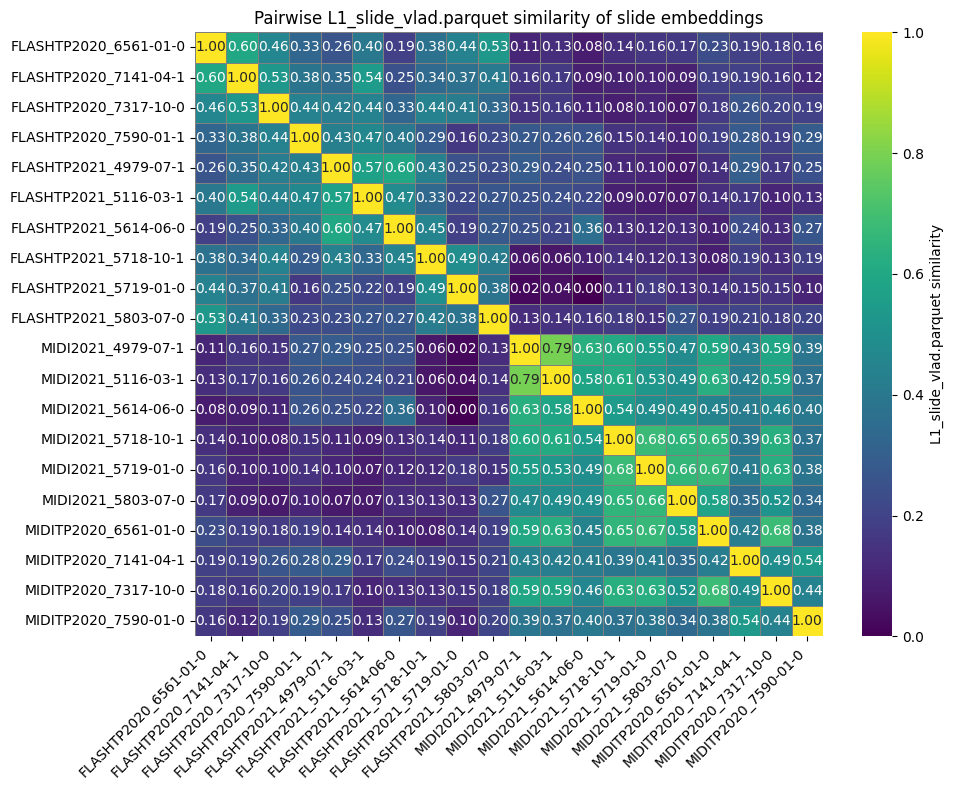

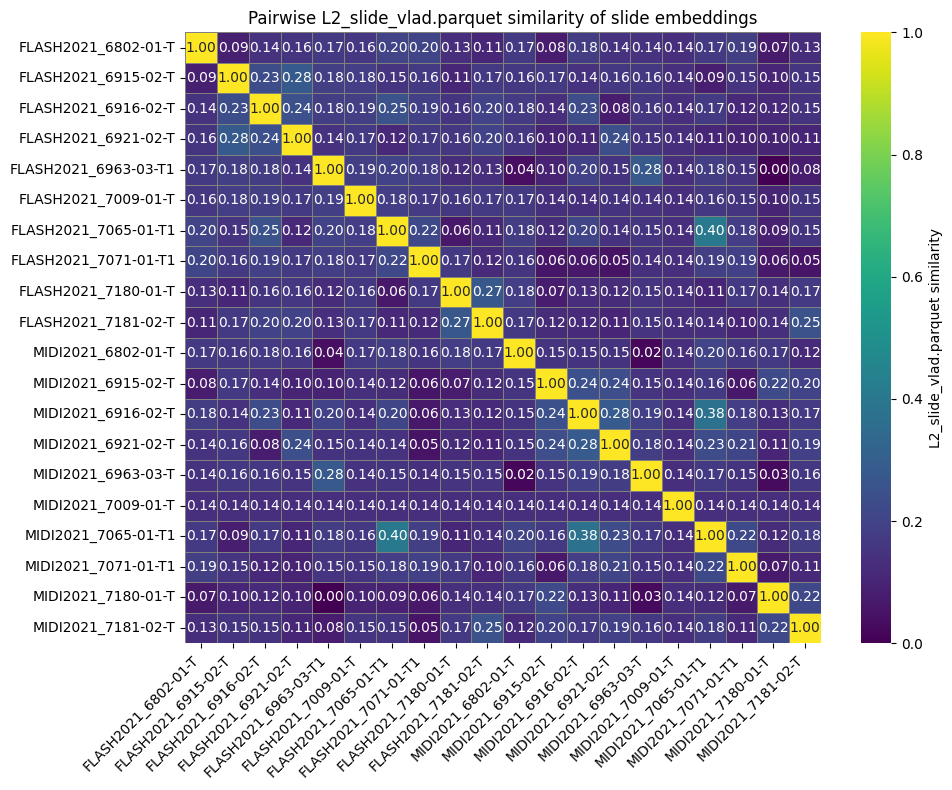

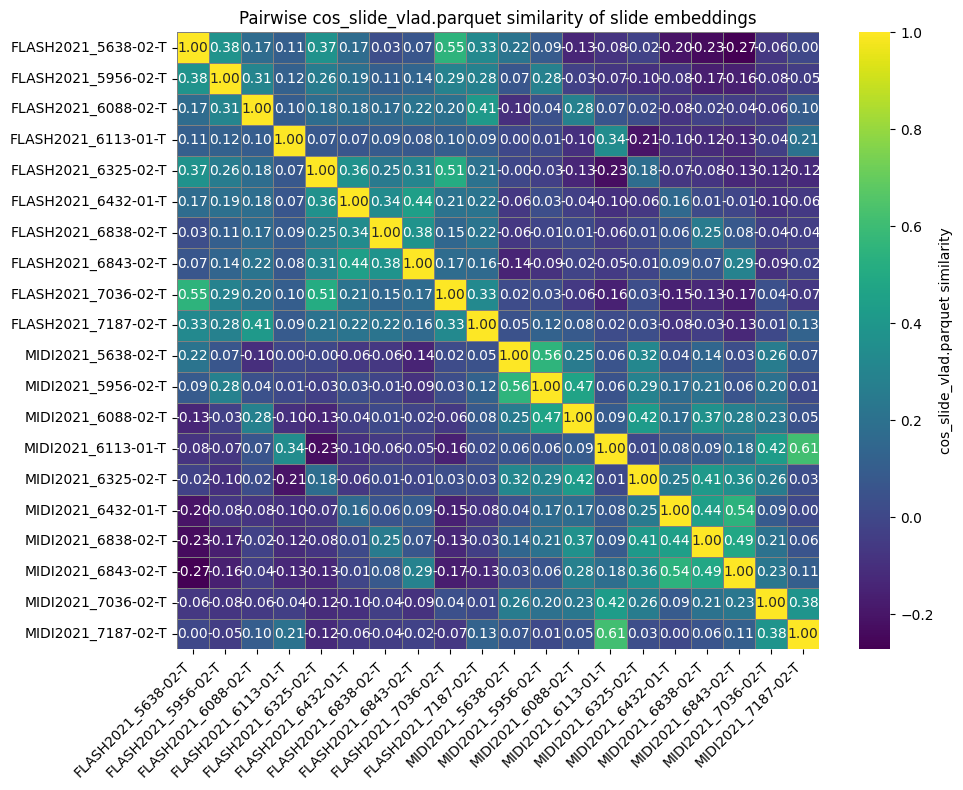

In [9]:
l1_simmilarity(slide_paths[0], "slide_vlad.parquet")
l2_simmilarity(slide_paths[1], "slide_vlad.parquet")
cos_simmilarity(slide_paths[2], "slide_vlad.parquet")

In [10]:
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.decomposition import PCA

def remove_pc1_and_rescale(vlad_vectors):
    """
    1. Removes Scanner Bias (PC1)
    2. Rescales the output so similarities look 'normal' (0 to 1).
    """
    # 1. Convert to Numpy
    if isinstance(vlad_vectors, torch.Tensor):
        X = vlad_vectors.cpu().numpy()
    else:
        X = vlad_vectors.copy()

    # --- STEP 1: Power Norm ---
    # Standard square root to dampen peaks
    X = np.sign(X) * np.sqrt(np.abs(X))

    # --- STEP 2: PCA De-Noising ---
    # Fit on the 20 slides
    n_components = min(X.shape[0], X.shape[1])
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X)
    
    # === THE FIX: Zero out PC1 ===
    # This removes the one dominant 'Scanner' signal
    X_pca[:, 0] = 0.0  # Remove PC1
    #X_pca[:, 1] = 0.0  # Remove PC2
    
    # Inverse transform to get back to original space
    X_clean = pca.inverse_transform(X_pca)

    # --- STEP 3: L2 Normalize ---
    X_final = torch.from_numpy(X_clean).float()
    X_final = F.normalize(X_final, p=2, dim=1)
    
    return X_final

def get_scaled_similarity_matrix(embeddings):
    """
    Computes Cosine Similarity and stretches the values 
    so the best matches are ~1.0 and worst are ~0.0.
    """
    # 1. Standard Cosine Sim (-1 to 1)
    # But because we removed PC1, values might be tiny (e.g. 0.05 to 0.15)
    raw_sim = embeddings @ embeddings.T
    
    # 2. Smart Rescaling
    # We ignore the diagonal (self-matches) for calculating min/max
    mask = ~torch.eye(raw_sim.shape[0], dtype=bool)
    valid_scores = raw_sim[mask]
    
    min_val = valid_scores.min()
    max_val = valid_scores.max()

    # Linear Stretch: (x - min) / (max - min)
    # This preserves the exact ranking but fixes the percentages
    scaled_sim = (raw_sim - min_val) / (max_val - min_val)
    
    # Fix the diagonal to exactly 1.0
    scaled_sim.fill_diagonal_(1.0)
    
    return scaled_sim


def calculate_sims(embedding_matrix, labels):
    # ==========================================
    # EXECUTION
    # ==========================================

    # 1. Clean the vectors (Delete PC1)
    clean_emb = remove_pc1_and_rescale(embedding_matrix)

    # 2. Get the "Nice Looking" Matrix
    sim_matrix = get_scaled_similarity_matrix(clean_emb)

    # 3. Check Top Matches
    # Fill diagonal with -1 to skip self
    sim_matrix.fill_diagonal_(-1)

    values, indices = torch.topk(sim_matrix, k=1, dim=1)

    hits = 0
    for i in range(len(indices)):
        slide_a = labels[i]
        slide_b = labels[indices[i].item()]
        if (slide_a[-14:] == slide_b[-14:]):
            hits += 1
        
    print(f"perfect hits: {hits}/20")


    #plt.figure(figsize=(10, 8))
    #sns.heatmap(
    #    sim_matrix,
    #    xticklabels=labels,
    #    yticklabels=labels,
    #    cmap="viridis",
    #    annot=True,
    #    fmt=".2f",                    
    #    linewidths=0.5,
    #    linecolor="gray",
    #    annot_kws={"fontsize": 10}
    #)
    #plt.xticks(rotation=45, ha="right", fontsize=10)
    #plt.yticks(rotation=0, fontsize=10)
    #plt.tight_layout()



In [14]:
print("Normal cos similarity")

print("\nProstate rgb filter")
embedding_matrix, labels = load_embeddings("/mnt/projects/ri_scale/privagams/prostate_rgb_filter", "slide_vlad.parquet")
calculate_sims(embedding_matrix, labels)

print("\nBreast rgb filter")
embedding_matrix, labels = load_embeddings("/mnt/projects/ri_scale/privagams/breast_rgb_filter", "slide_vlad.parquet")
calculate_sims(embedding_matrix, labels)

print("\nColon rgb filter")
embedding_matrix, labels = load_embeddings("/mnt/projects/ri_scale/privagams/colon_rgb_filter", "slide_vlad.parquet")
calculate_sims(embedding_matrix, labels)

print("\nStained cos similarity")
print("\nProstate stains")
embedding_matrix, labels = load_embeddings("/mnt/projects/ri_scale/privagams/prostate_stains", "slide_vlad.parquet")
calculate_sims(embedding_matrix, labels)

print("\nBreast stains")
embedding_matrix, labels = load_embeddings("/mnt/projects/ri_scale/privagams/breast_stains", "slide_vlad.parquet")
calculate_sims(embedding_matrix, labels)

print("\nColon stains")
embedding_matrix, labels = load_embeddings("/mnt/projects/ri_scale/privagams/colon_stains", "slide_vlad.parquet")
calculate_sims(embedding_matrix, labels)

print("\nNormalized cos similarity")
print("\nProstate Normalized")
embedding_matrix, labels = load_embeddings("/mnt/projects/ri_scale/privagams/prostate_normalized", "slide_vlad.parquet")
calculate_sims(embedding_matrix, labels)

print("\nBreast Normalized")
embedding_matrix, labels = load_embeddings("/mnt/projects/ri_scale/privagams/breast_normalized", "slide_vlad.parquet")
calculate_sims(embedding_matrix, labels)

print("\nColon Normalized")
embedding_matrix, labels = load_embeddings("/mnt/projects/ri_scale/privagams/colon_normalized", "slide_vlad.parquet")
calculate_sims(embedding_matrix, labels)

Normal cos similarity

Prostate rgb filter
/mnt/projects/ri_scale/privagams/prostate_rgb_filter
perfect hits: 11/20

Breast rgb filter
/mnt/projects/ri_scale/privagams/breast_rgb_filter
perfect hits: 13/20

Colon rgb filter
/mnt/projects/ri_scale/privagams/colon_rgb_filter
perfect hits: 7/20

Stained cos similarity

Prostate stains
/mnt/projects/ri_scale/privagams/prostate_stains
perfect hits: 13/20

Breast stains
/mnt/projects/ri_scale/privagams/breast_stains
perfect hits: 18/20

Colon stains
/mnt/projects/ri_scale/privagams/colon_stains
perfect hits: 20/20

Normalized cos similarity

Prostate Normalized
/mnt/projects/ri_scale/privagams/prostate_normalized
perfect hits: 12/20

Breast Normalized
/mnt/projects/ri_scale/privagams/breast_normalized
perfect hits: 9/20

Colon Normalized
/mnt/projects/ri_scale/privagams/colon_normalized
perfect hits: 15/20


In [52]:
def cos_simmilarity(emb_matrix, labels):
    emb_matrix = torch.sign(emb_matrix) * torch.sqrt(torch.abs(emb_matrix))
    X_norm = F.normalize(emb_matrix, p=2, dim=1)
    cosine_sim = X_norm @ X_norm.T
    return save_simmilarity(cosine_sim, labels)

def l1_simmilarity(emb_matrix, labels):
    l1_distance_matrix = torch.cdist(emb_matrix, emb_matrix, p=1)

    D_min = l1_distance_matrix.min()
    D_max = l1_distance_matrix.max()

    # 2. Normalizace matice na rozsah [0, 1]
    # (Odečteme minimum a vydělíme rozsahem)
    D_range = D_max - D_min
    # Ošetření případu, kdy D_range je nula (např. matice plná stejných hodnot)
    if D_range == 0:
        similarity_matrix = torch.ones_like(l1_distance_matrix)
    else:
        D_norm = (l1_distance_matrix - D_min) / D_range
        
        # 3. Inverze (Odečtení od 1)
        similarity_matrix = 1 - D_norm

    return save_simmilarity(similarity_matrix, labels)

def l2_simmilarity(emb_matrix, labels):
    l2_distance_matrix = torch.cdist(emb_matrix, emb_matrix, p=2)

    D_min = l2_distance_matrix.min()
    D_max = l2_distance_matrix.max()

    # 2. Normalizace matice na rozsah [0, 1]
    # (Odečteme minimum a vydělíme rozsahem)
    D_range = D_max - D_min
    # Ošetření případu, kdy D_range je nula (např. matice plná stejných hodnot)
    if D_range == 0:
        similarity_matrix = torch.ones_like(l2_distance_matrix)
    else:
        D_norm = (l2_distance_matrix - D_min) / D_range
        
        # 3. Inverze (Odečtení od 1)
        similarity_matrix = 1 - D_norm

    return save_simmilarity(similarity_matrix, labels)

def save_simmilarity(sim_matrix, labels):
    name="xd"

    sim_matrix_mod = sim_matrix.clone()
    sim_matrix_mod.fill_diagonal_(-2.0)
    most_similar_indices = torch.argmax(sim_matrix_mod, dim=1)

    hits = 0
    for i in range(len(labels)):
        slide_a = labels[i]
        slide_b = labels[most_similar_indices[i]]
        #print(slide_a[-14:])
        #print(slide_b[-14:])
        if (slide_a[-14:] == slide_b[-14:]):
            hits += 1
        
        #print(f"slide {labels[i]} is most simmilar with slide {labels[most_similar_indices[i]]}")
    print(f"perfect hits: {hits}/20")


    #print(f"Number of MIDI/FLASH matches for {name} is {count}, R_s= {count/len(x_labels)}")
    #print(f"length of {name} is {len(x_labels)}")
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        sim_matrix,
        xticklabels=labels,
        yticklabels=labels,
        cmap="viridis",
        annot=True,
        fmt=".2f",                    
        linewidths=0.5,
        linecolor="gray",
        cbar_kws={"label": f"{name} similarity"},
        annot_kws={"fontsize": 10}
    )
    plt.title(f"Pairwise {name} similarity of slide embeddings")
    plt.xticks(rotation=45, ha="right", fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()

    return 0